# 03. Modelli Non Supervisionati (Clustering)
In questo notebook esploriamo come gli algoritmi di clustering (KMeans e Spectral Clustering) riescono a raggruppare i campioni e confrontiamo i risultati con le diagnosi reali.

In [5]:
import os
import sys
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import umap

# Path moduli
sys.path.append(os.path.abspath('modules'))

from models_factory import get_unsupervised_model, save_model, save_results
from visualization import (
    plot_cluster_comparison, 
    plot_cluster_comparison_3d, 
    plot_contingency_matrix, 
    plot_umap_2d
)

SEED = 42
N_CLUSTERS = 5

## 1. Caricamento Dati Preprocessati

In [6]:
data = joblib.load('data_processed/processed_data.joblib')
X_pca = data['X_pca']
y_true = data['y_enc']
class_names = data['classes']

print(f"Dataset per clustering: {X_pca.shape[0]} campioni e {X_pca.shape[1]} componenti PCA.")

Dataset per clustering: 801 campioni e 503 componenti PCA.


## 2. Esecuzione Clustering
Applichiamo KMeans e Spectral Clustering e analizziamo i raggruppamenti trovati.


--- KMEANS ---
Adjusted Rand Index (ARI): 0.7970
Normalized Mutual Info (NMI): 0.8578
Silhouette Score: 0.1545


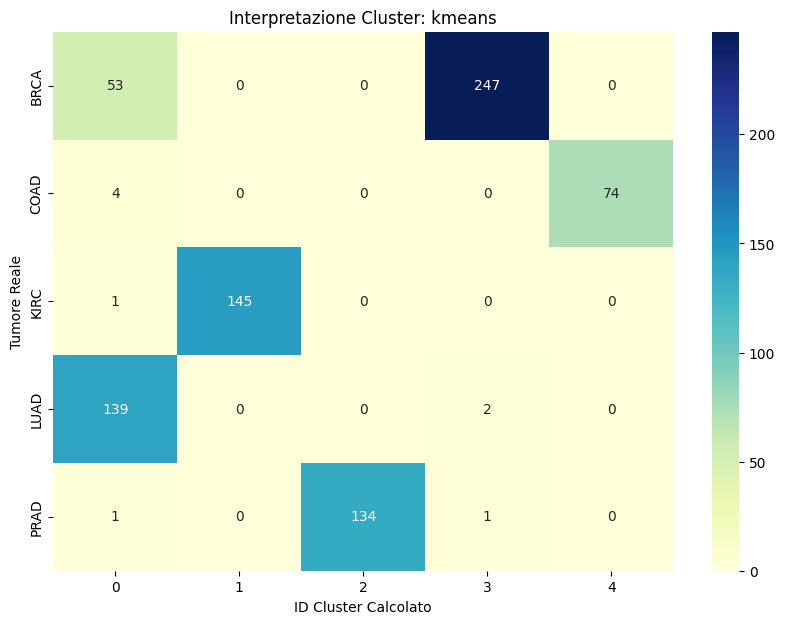

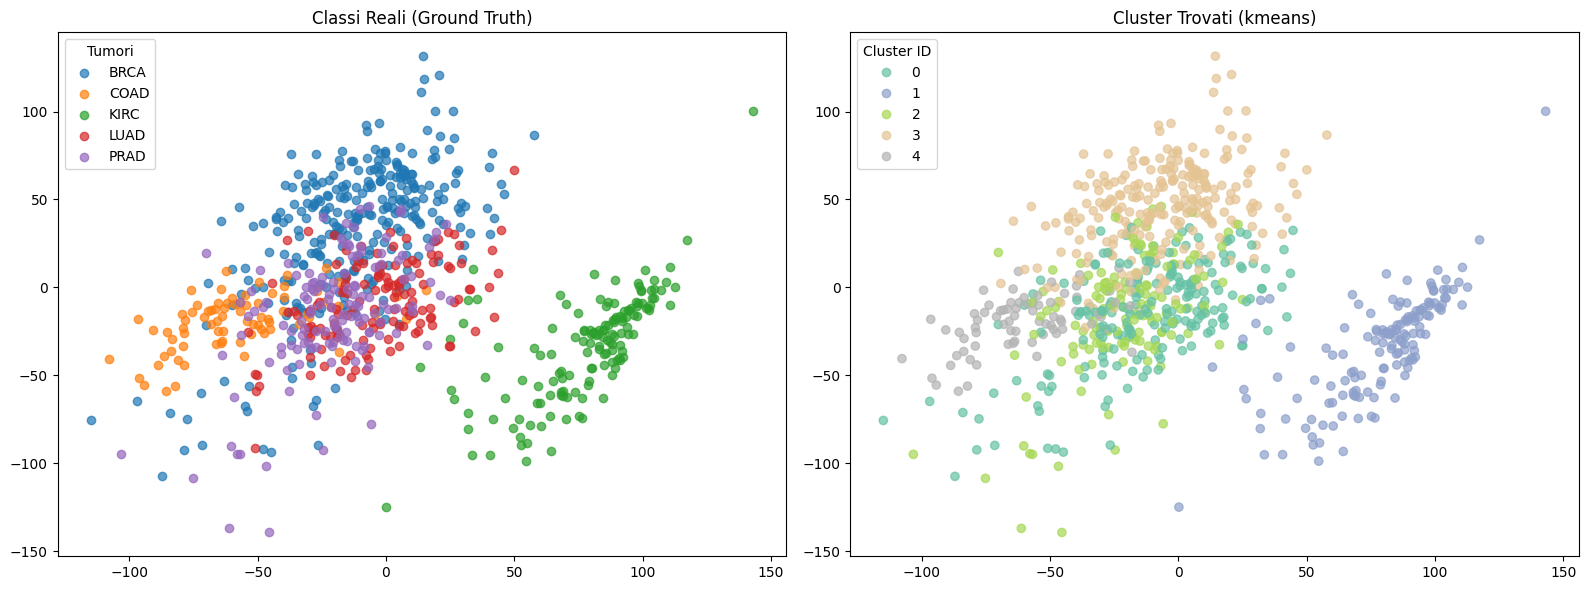

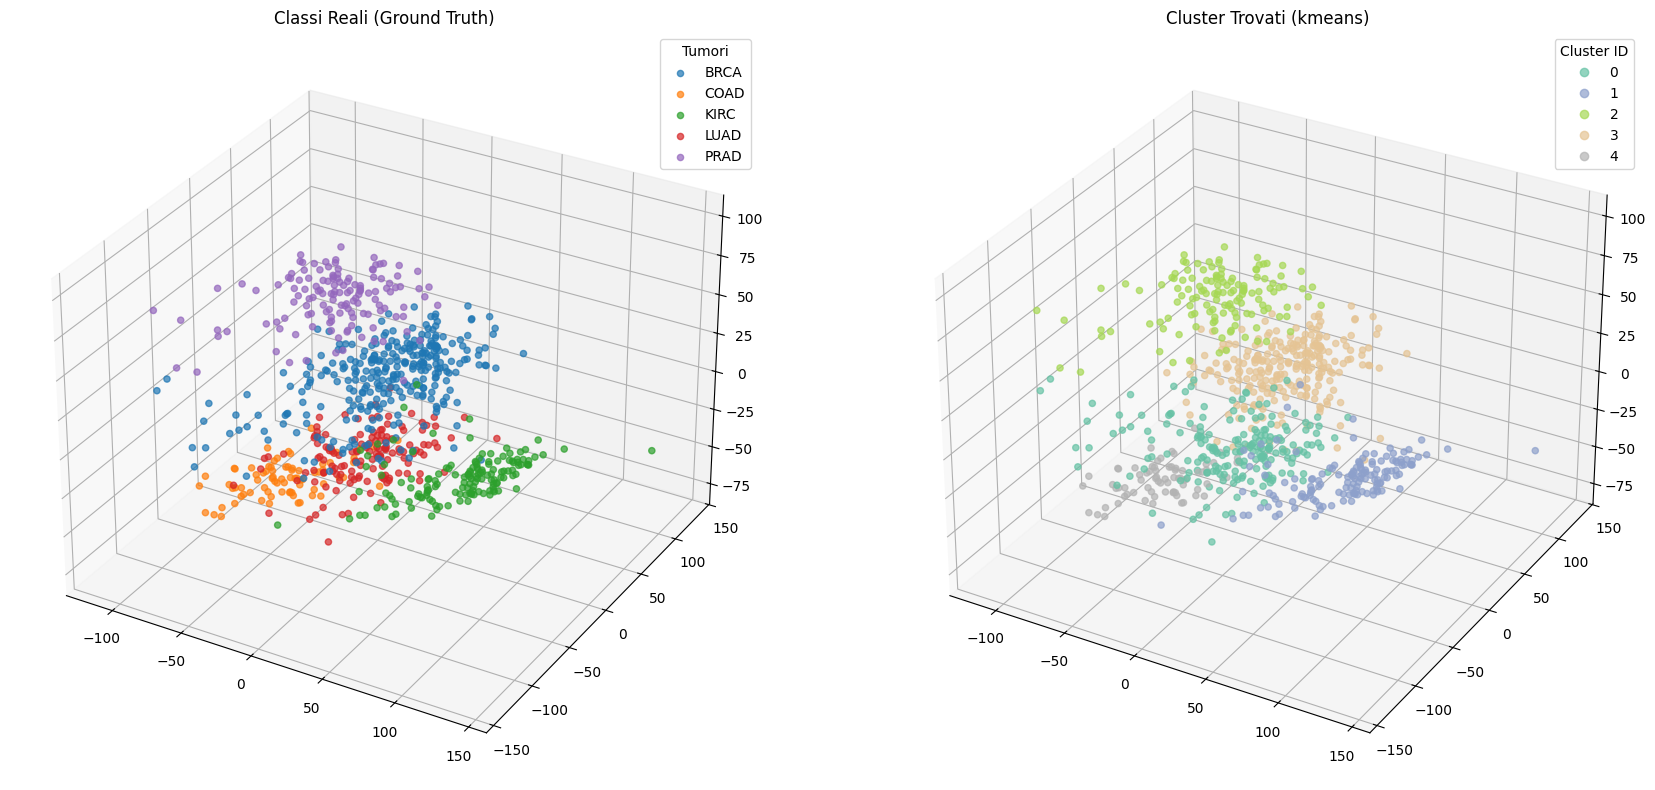


--- SPECTRAL ---
Adjusted Rand Index (ARI): 0.9832
Normalized Mutual Info (NMI): 0.9755
Silhouette Score: 0.1560


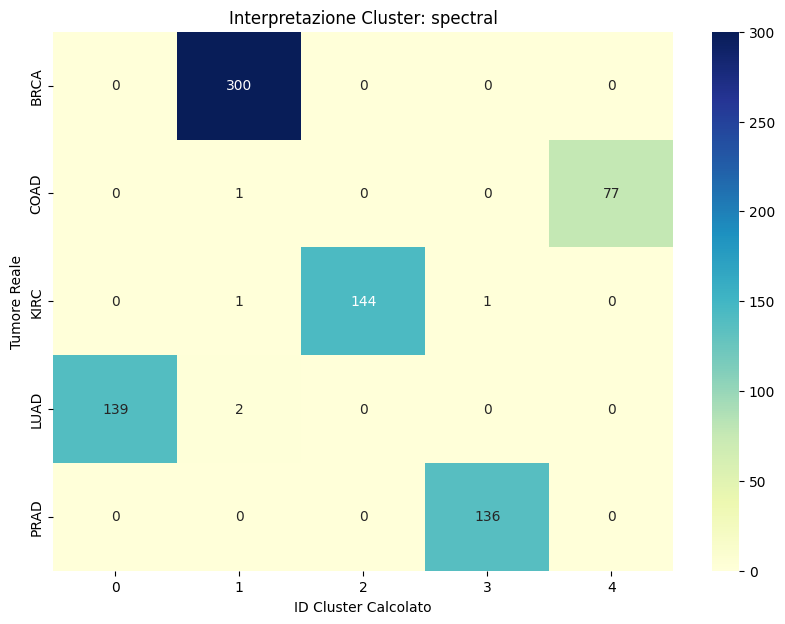

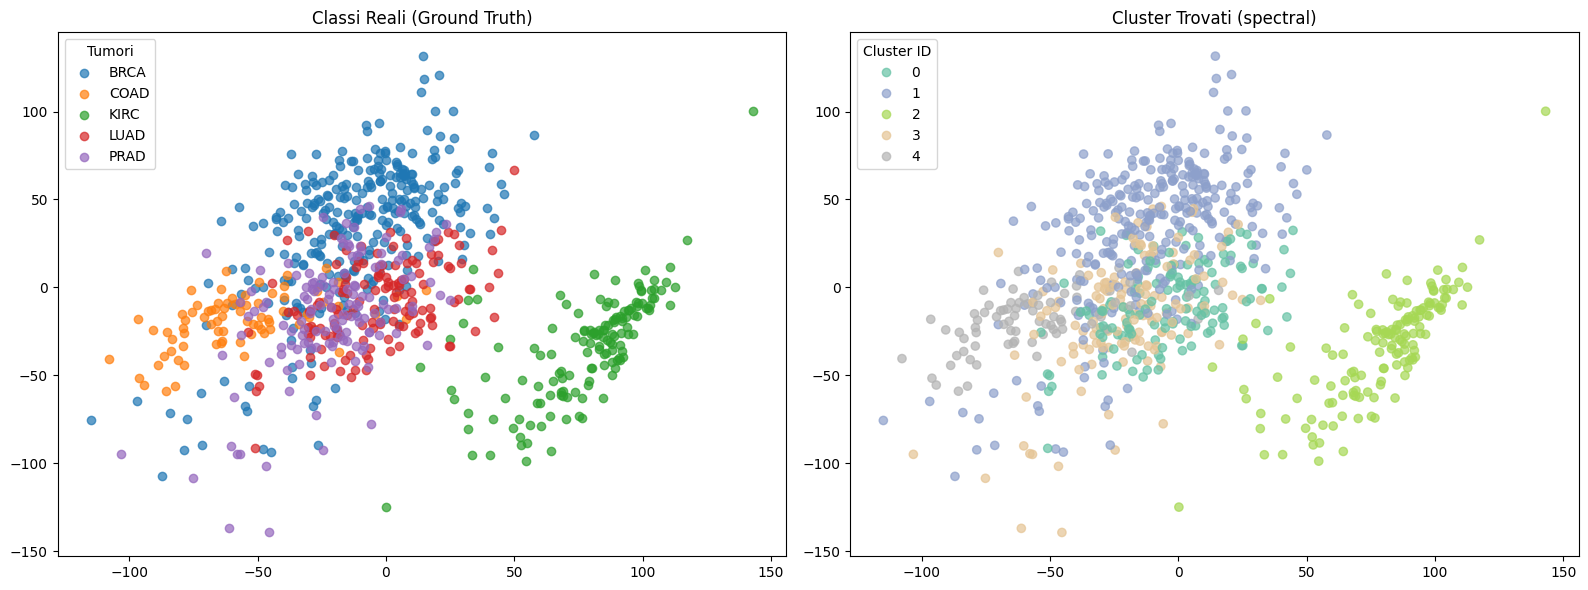

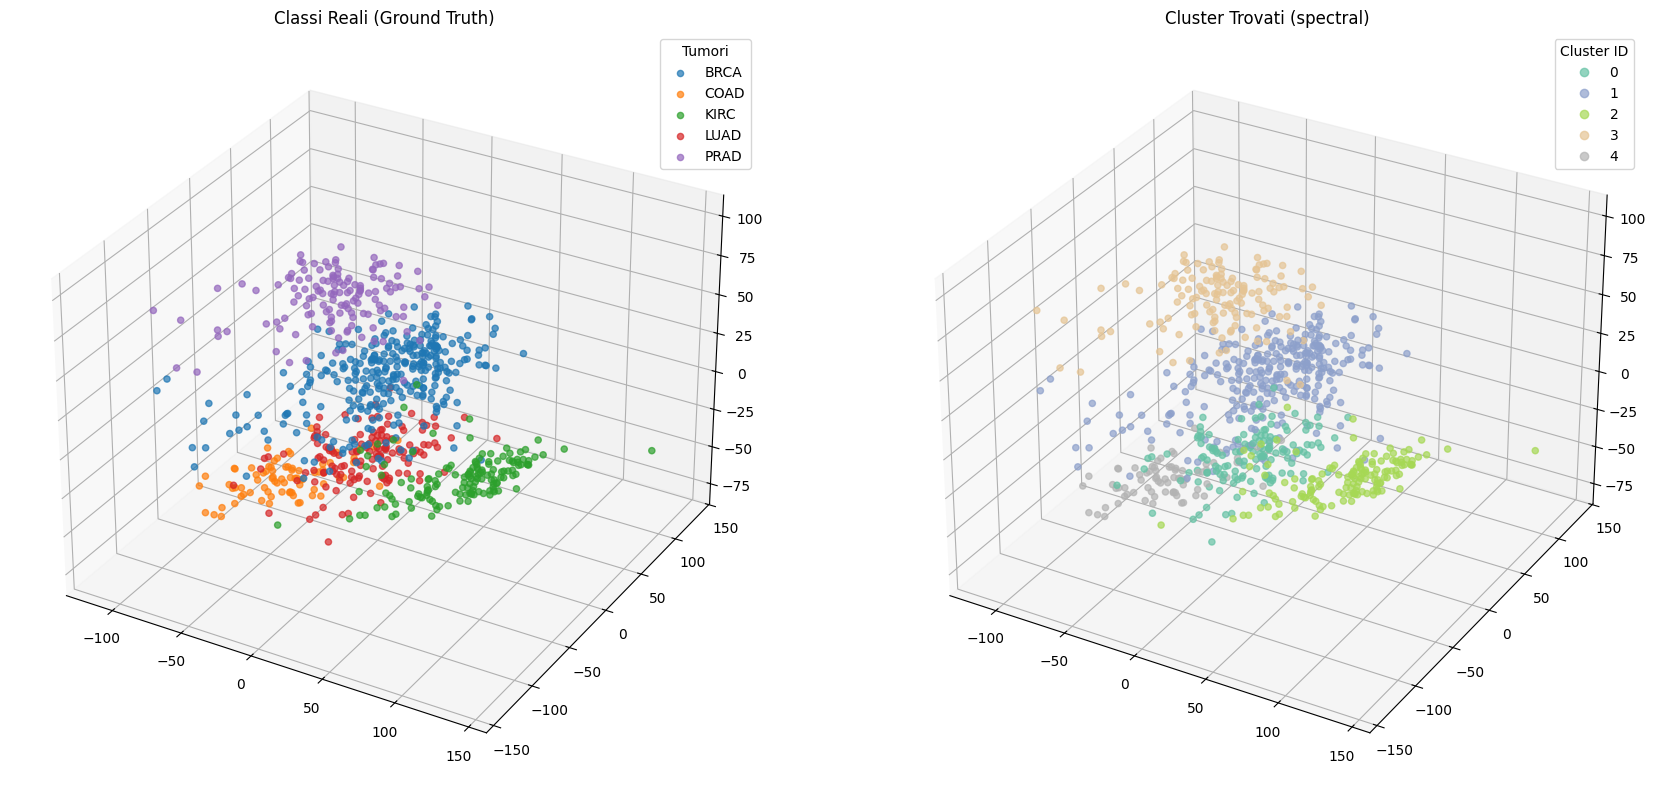


Clustering completato.


In [10]:
clustering_algorithms = ['kmeans', 'spectral']
all_results = {}
predictions = {}

for alg_name in clustering_algorithms:
    print(f"\n--- {alg_name.upper()} ---")
    
    # Ottieni e addestra il modello
    model = get_unsupervised_model(alg_name, n_clusters=N_CLUSTERS, seed=SEED)
    
    # Fit e predizione
    y_pred = model.fit_predict(X_pca)
    predictions[alg_name] = y_pred
    
    # Calcolo Metriche
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    sil = silhouette_score(X_pca, y_pred)
    
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
    print(f"Silhouette Score: {sil:.4f}")
    
    # 1. Matrice di Contingenza (Analisi dei gruppi)
    plot_contingency_matrix(y_true, y_pred, class_names, title=f"Interpretazione Cluster: {alg_name}")
    
    # 2. Confronto Visuale PCA (2D)
    plot_cluster_comparison(X_pca, y_true, y_pred, class_names, model_name=alg_name)
    
    # 3. Confronto Visuale PCA (3D)
    plot_cluster_comparison_3d(X_pca, y_true, y_pred, class_names, model_name=alg_name)
    
    # Salvataggio
    model_path = save_model(model, alg_name)
    save_results({'ari': float(ari), 'nmi': float(nmi), 'silhouette': float(sil), 'model_path': model_path}, alg_name)
    all_results[alg_name] = ari

print("\nClustering completato.")

## 3. Visualizzazione Avanzata (UMAP)
Sebbene il clustering sia stato fatto in spazio PCA, visualizziamo i risultati in spazio UMAP per una separazione visiva più netta.

c:\Users\gvnnp\Desktop\Python\ML_Info\Prove_MachineLearning_Info\VE\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


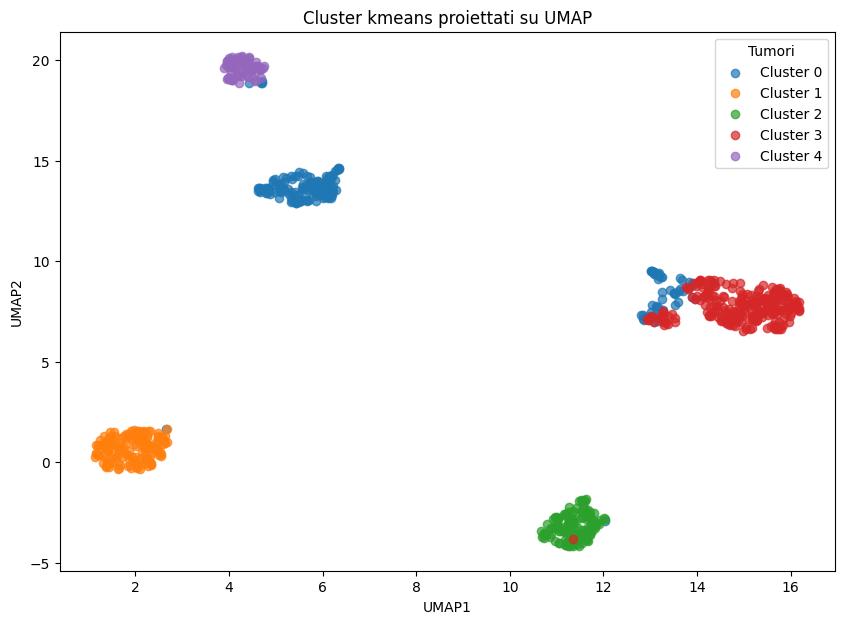

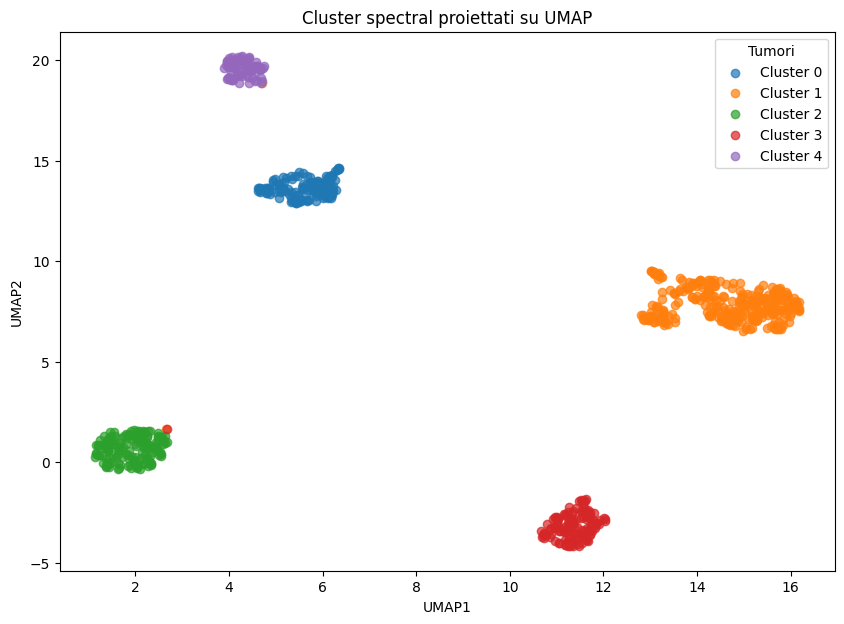

In [8]:
reducer = umap.UMAP(n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_pca)

for alg_name in clustering_algorithms:
    plot_umap_2d(X_umap, predictions[alg_name], [f"Cluster {i}" for i in range(N_CLUSTERS)], title=f"Cluster {alg_name} proiettati su UMAP")